[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ArjunMurlidhar/Single_Lens_Fitting/blob/main/pylima_demo.ipynb)

In [1]:
# Run this cell if you are using Google Colab
!pip install pyLIMA

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.7/72.7 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.6/19.6 MB 62.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.1/11.1 MB 98.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.4/47.4 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 448.2/448.2 kB 29.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 75.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.2/5.2 MB 72.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 59.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 40.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 328.3/328.3 kB 24.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 731.7/731.7 kB 47.7 MB/s eta 0:00:0

In [2]:
# Download the data file from GitHub (run this cell if you are using Google Colab)
!wget -q https://raw.githubusercontent.com/ArjunMurlidhar/Single_Lens_Fitting/main/pylima_demo.txt

In [3]:
from pyLIMA import event, telescopes
from pyLIMA.models import PSPL_model, FSPL_model
from pyLIMA.fits import LM_fit, DE_fit, MCMC_fit, TRF_fit
from pyLIMA.outputs import pyLIMA_plots
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

try:
    import google.colab
    %matplotlib inline
except ImportError:
    %matplotlib widget


## Load and plot the data

<>:2: SyntaxWarning: invalid escape sequence '\s'
<>:2: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_22423/581902758.py:2: SyntaxWarning: invalid escape sequence '\s'
  Roman_data = pd.read_table('pylima_demo.txt', sep='\s+', header=None)


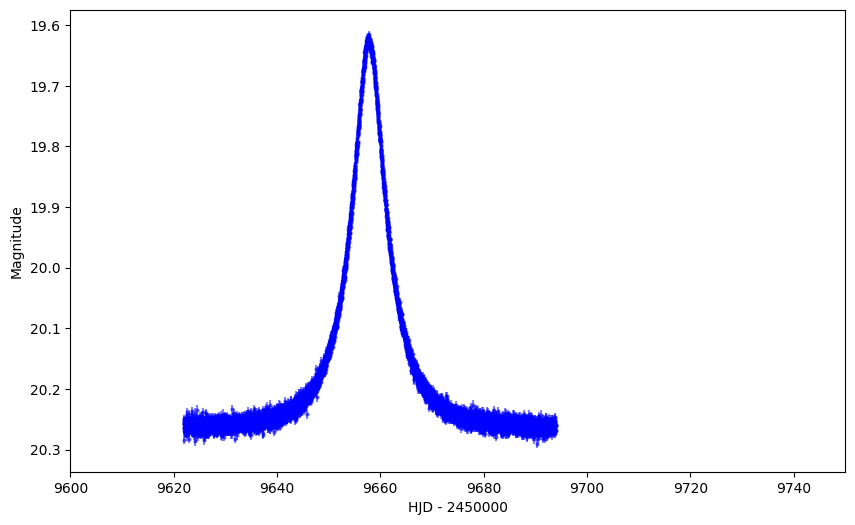

In [8]:
#Read the data file
Roman_data = pd.read_table('pylima_demo.txt', sep='\s+', header=None)
Roman_data.columns = ['time', 'mag', 'err_mag']
Roman_data['time'] = Roman_data['time'].astype(float)
Roman_data['mag'] = Roman_data['mag'].astype(float)
Roman_data['err_mag'] = Roman_data['err_mag'].astype(float)

#crop data to t_0 - 3*t_E to t_0 + 3*t_E
#data_bl = data_bl[(data_bl['HJD'] >= t_0 - 3*t_E) & (data_bl['HJD'] <= t_0 + 3*t_E)]
#Plot the light curve with error bars
plt.figure(figsize=(10, 6))
plt.errorbar(Roman_data['time'] - 2450000, Roman_data['mag'], yerr=Roman_data['err_mag'], fmt='o', c='blue', alpha=0.5, markersize=2.0)
plt.xlabel('HJD - 2450000')
plt.ylabel('Magnitude')
plt.xlim((9600, 9750))
#invert the y-axis
plt.gca().invert_yaxis()
plt.show()

## Fitting the event with pyLIMA

pyLIMA uses a modular approach with three main components:
1. **Event**: Contains all information about the microlensing event
2. **Telescopes**: Individual telescope data and properties
3. **Models**: The microlensing model to fit

In [9]:
#@title Basic pyLIMA Setup
# Create a new event
Roman_event = event.Event()
Roman_event.name = f'pyLIMA_1s1l_demo'

# Create synthetic data for demonstration
# In practice, you would load real data from files
np.random.seed(42)  # For reproducible results

# Create telescope object
lightcurve_data = np.column_stack(
    [
        Roman_data['time'],
        Roman_data['mag'],
        Roman_data['err_mag']
        ]
    )
Roman_W149 = telescopes.Telescope(
    name='Roman_W149',
    camera_filter='H',
    lightcurve=lightcurve_data.astype(float),
    lightcurve_names=['time', 'mag', 'err_mag'],
    lightcurve_units=['HJD', 'mag', 'mag']
)

# Add telescope to event
Roman_event.telescopes.append(Roman_W149)

# Set survey telescope (for alignment)
Roman_event.find_survey('Roman')

# Check event setup
Roman_event.check_event()

print(f"Event '{Roman_event.name}' created with {len(Roman_event.telescopes)} telescope(s)")
print(f"Data points: {len(Roman_W149.lightcurve)}")

check_event  : Everything looks fine...
Event 'pyLIMA_1s1l_demo' created with 1 telescope(s)
Data points: 38568



Running LM fit...
Selecting Roman_W149 to estimate u0, tE and fs
initial_guess  : Initial parameters guess SUCCESS
Using guess:  [2459657.748444, 0.6269400324057129, 5.076366999652237, 691.611234597385, 716.0993195349611]
fit  : Levenberg-Marquardt fit SUCCESS
best model:
OrderedDict([('t0', np.float64(2459657.782345089)),
             ('u0', np.float64(0.3077557064315996)),
             ('tE', np.float64(8.36949968375563)),
             ('fsource_Roman_W149', np.float64(241.67281194132389)),
             ('ftotal_Roman_W149', np.float64(715.364904494635)),
             ('chi2', np.float64(39314.56110940218))])

Fit Results:
[2.45965778e+06 3.07755706e-01 8.36949968e+00 2.41672812e+02
 7.15364904e+02]

Chi-squared: 39314.56


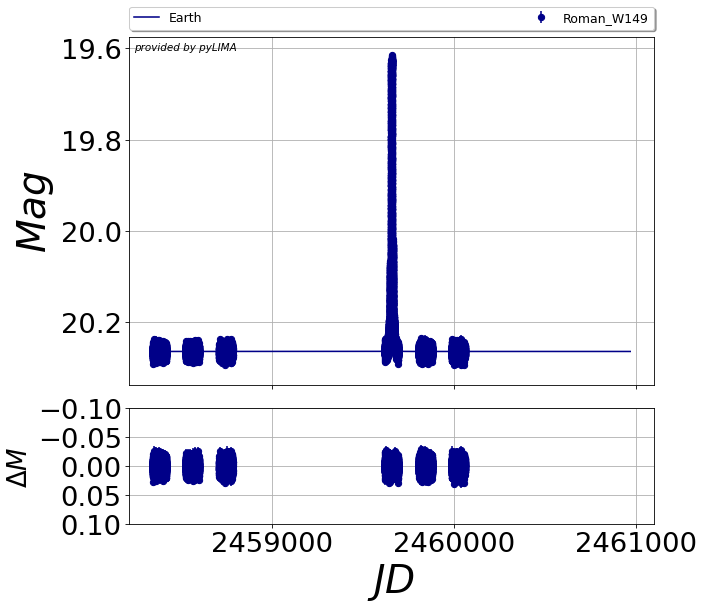

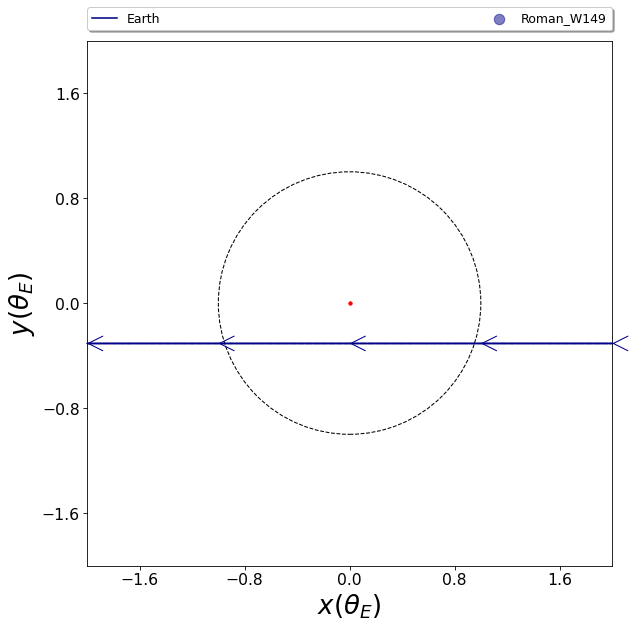

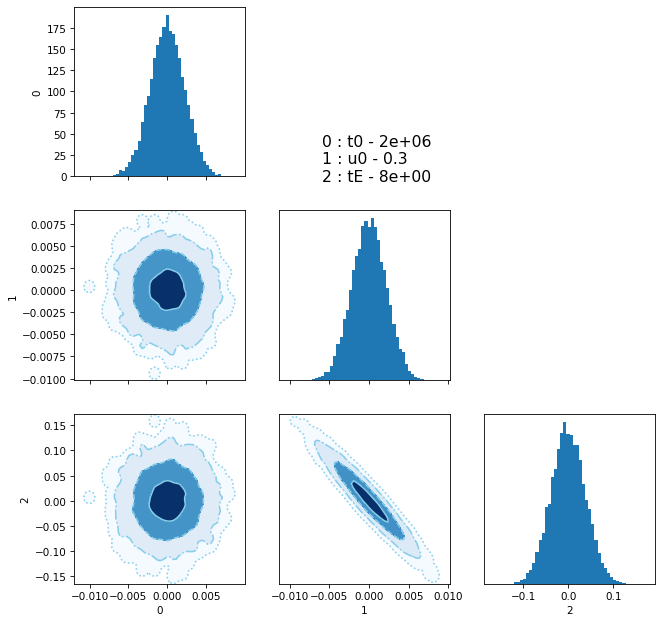

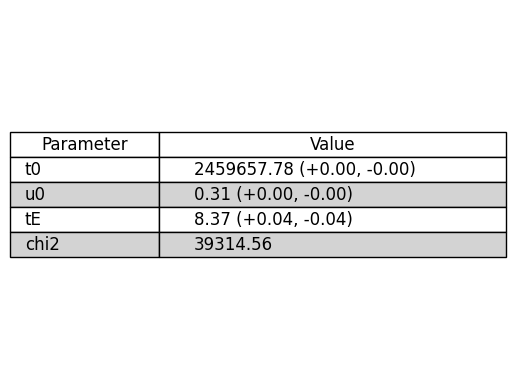

In [10]:
#@title PSPL Model Setup and Fitting
# Create PSPL model
pspl = PSPL_model.PSPLmodel(Roman_event)

# Initialize fit with Levenberg-Marquardt algorithm
my_fit = LM_fit.LMfit(pspl)

# Run the fit
print("\nRunning LM fit...")
my_fit.fit()
my_fit.fit_outputs()

# Display results
print("\nFit Results:")
print(my_fit.fit_results['best_model'])
print(f"\nChi-squared: {my_fit.fit_results['chi2']:.2f}")



In [ ]:
delta_chi2 = my_fit.fit_results['chi2'] - (len(Roman_data['time']) - 5)
print(f"Delta Chi-squared: {delta_chi2:.2f}")
print("Reduced Chi-squared: ", my_fit.fit_results['chi2'] / (len(Roman_data['time']) - 5))


Delta Chi-squared: 751.56
Reduced Chi-squared:  1.019489176397121
